C:\Users\jt725\AppData\Local\Temp\ipykernel_30136\2914721614.py:26: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  avg_per_bin = df.groupby('range')['height'].mean()


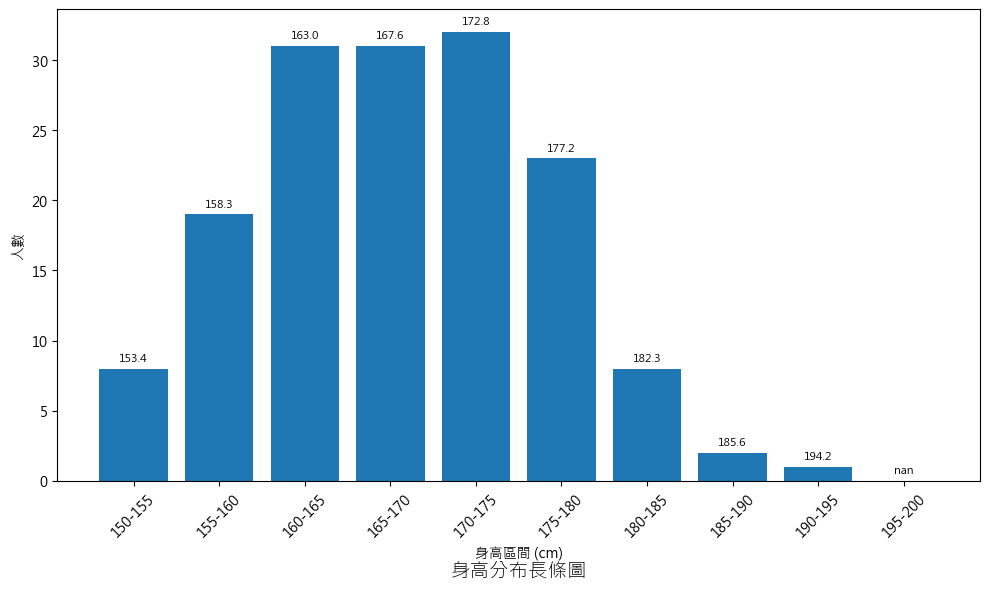

In [4]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlite3 as s
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
# 將資料放入列表

conn=s.connect('D://database//學校身體資訊.db')#建立資料庫連線

data=conn.execute('select 身高 from student ')
    
  
# 轉為 DataFrame 方便處理
df = pd.DataFrame(data, columns=['height'])

# 設定分布區間（例如每5公分一區）
bins = np.arange(150, 200 + 5, 5)
labels = [f"{bins[i]}-{bins[i+1]}" for i in range(len(bins)-1)]
df['range'] = pd.cut(df['height'], bins=bins, labels=labels, include_lowest=True)

# 統計每個區間的人數
count_per_bin = df['range'].value_counts().sort_index()

# 計算每個區間的平均身高
avg_per_bin = df.groupby('range')['height'].mean()

# 畫長條圖（x 軸是區間，y 軸是人數）
plt.figure(figsize=(10,6))
bars = plt.bar(count_per_bin.index.astype(str), count_per_bin.values)

# 標籤
plt.xlabel('身高區間 (cm)')
plt.ylabel('人數')
plt.text(
    0.5, -0.17, '身高分布長條圖',             # x=0.5 居中, y=-0.1 在圖表下方
    ha='center', va='top',
    transform=plt.gca().transAxes,            # 使用相對座標 (0~1)
    fontsize=14, fontweight='light'
)


# 在長條上顯示平均值（四捨五入至1位小數）
for rect, avg in zip(bars, avg_per_bin):
    plt.text(rect.get_x() + rect.get_width()/2, rect.get_height() + 0.3,
             f"{avg:.1f}", ha='center', va='bottom', fontsize=8, color='black')

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
conn.close()

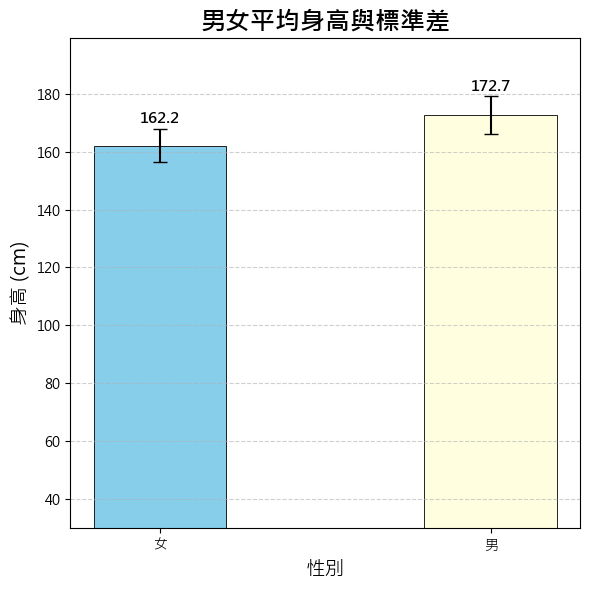

In [35]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlite3 as s

# 字體設定（支援中文）
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False

# 建立資料庫連線
conn = s.connect('D://database//學校身體資訊.db')

# 讀取性別與身高資料
df = pd.read_sql_query("SELECT 性別, 身高 FROM student WHERE 身高 IS NOT NULL", conn)
conn.close()

# 分別計算平均值與標準差
group_stats = df.groupby("性別")["身高"].agg(['mean', 'std', 'count']).reset_index()

# 準備畫圖資料
x_labels = group_stats["性別"]
means = group_stats["mean"]
stds = group_stats["std"]

# 科展標準風格圖
plt.figure(figsize=(6,6))
bars = plt.bar(x_labels, means, yerr=stds, capsize=5, color=['skyblue', 'lightyellow'], edgecolor='black', linewidth=0.6,width=0.4)

# 圖片標題與標籤
plt.title("男女平均身高與標準差", fontsize=18, weight='bold')
plt.xlabel("性別", fontsize=14)
plt.ylabel("身高 (cm)", fontsize=14)

# 在長條上方顯示平均值（含小數）
for i, rect in enumerate(bars):
    plt.text(rect.get_x() + rect.get_width()/2, rect.get_height() + stds[i] + 0.5,
             f"{means[i]:.1f}", ha='center', va='bottom', fontsize=11, color='black', weight='bold')
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.ylim(30, max(means + stds) + 20)  # 上方留空間給誤差棒
plt.tight_layout()
plt.show()


In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sqlite3 as s
plt.rcParams['font.sans-serif'] = ['Microsoft JhengHei', 'SimHei', 'Arial Unicode MS']
plt.rcParams['axes.unicode_minus'] = False
conn = s.connect('D://database//學校身體資訊.db')
data=conn.execute('select 身高 from student where 性別 = "男" order by 身高')

 

